# 14. Trade Network Analysis

Part of the `nuclearff` [User Tutorial](https://nolmacdonald.github.io/nuclearff/tutorial/index.html) notebook series -- every notebook shares one running `./demo` directory and depends on the ones before it having already run. See [README.md](README.md) for the full run order. Run `13_league_history.ipynb` first.

`nuclearff.report.trades` turns a league's stored trade history (`04_capturing_a_league.ipynb`'s `sleeper_transactions`) into ten different views of who trades, who trades with whom, and how that's changed over time. This notebook walks through all ten, grounded in one real league's real data (`1367225133634191360`, `NUCLEARFF REDRAFT`). No new Sleeper fetching happens here -- every function below only reads and renders what `04_capturing_a_league.ipynb` already stored. Mirrors the [Trade Network Analysis](https://nolmacdonald.github.io/nuclearff/tutorial/14_trade_network.html) docs page.

## Trade edges and manager totals

`load_trades` explodes every stored trade transaction into one row per manager pair per trade; `manager_trade_counts` rolls that up per manager:

In [1]:
import polars as pl

from nuclearff.duckdb_io import read_table
from nuclearff.sleeper.trades import load_trades, manager_trade_counts

db_path = "./demo/data/cache/nuclearff.duckdb"
edges = load_trades(db_path)
counts = manager_trade_counts(edges)
print(edges.height, "trade edges")
counts.sort("trades", descending=True).head(3)

5 trade edges


manager,trades,unique_partners,most_frequent_partner,trades_with_partner
str,u32,u32,str,u32
"""nolmacdonald""",3,3,"""BigCookie96""",1
"""casitzmann""",3,3,"""BigCookie96""",1
"""BigCookie96""",2,2,"""casitzmann""",1


The most active trader stands out by a wide margin in the real output above. Note `trades` counts **distinct trades, not trade relationships** -- Sleeper allows more than two rosters in a single trade, and this league has real ones: a three-team trade counts once for each of the three managers involved, not twice for the two other parties each of them touches.

## Including managers who never traded

`manager_trade_counts` only returns managers who appear in `edges` -- several of this league's real all-time managers never made a trade and are absent entirely. Join against the full manager roster from `sleeper_standings` (`04_capturing_a_league.ipynb`) to include them at an explicit zero -- exactly what `report trades` does for you on the command line:

In [2]:
standings = read_table(db_path, "sleeper_standings")
all_managers = sorted({name for name in standings["display_name"].to_list() if name})

counts_full = (
    pl.DataFrame({"manager": all_managers})
    .join(counts, on="manager", how="left")
    .with_columns(
        pl.col("trades").fill_null(0),
        pl.col("unique_partners").fill_null(0),
        pl.col("trades_with_partner").fill_null(0),
    )
)
print(
    f"{counts_full.filter(pl.col('trades') == 0).height} of {counts_full.height} managers never traded"
)

10 of 15 managers never traded


The rest of this notebook uses `counts_full` (and an equally-densified trade matrix, below) so every chart includes every real manager, not just the ones who show up in trade data.

> **Why this matters:** this densification step is the exact bug this project shipped and then fixed in its own dashboard (issue #177): it's easy to write `manager_trade_counts(edges)` once, render straight from it, and never notice that a zero-trade manager silently vanished -- the chart still renders, it just quietly under-represents the league. Whenever you build a per-manager view from trade data yourself, always join against the full roster first, the way this cell does.

## Trades by manager, and between managers

`render_trades_by_manager` draws a horizontal bar chart, one bar per manager:

In [3]:
from nuclearff.report import render_trades_by_manager

render_trades_by_manager(
    counts_full.select("manager", "trades"),
    "./demo/data/artifacts/1367225133634191360-trades/trades_by_manager.png",
)

PosixPath('demo/data/artifacts/1367225133634191360-trades/trades_by_manager.png')

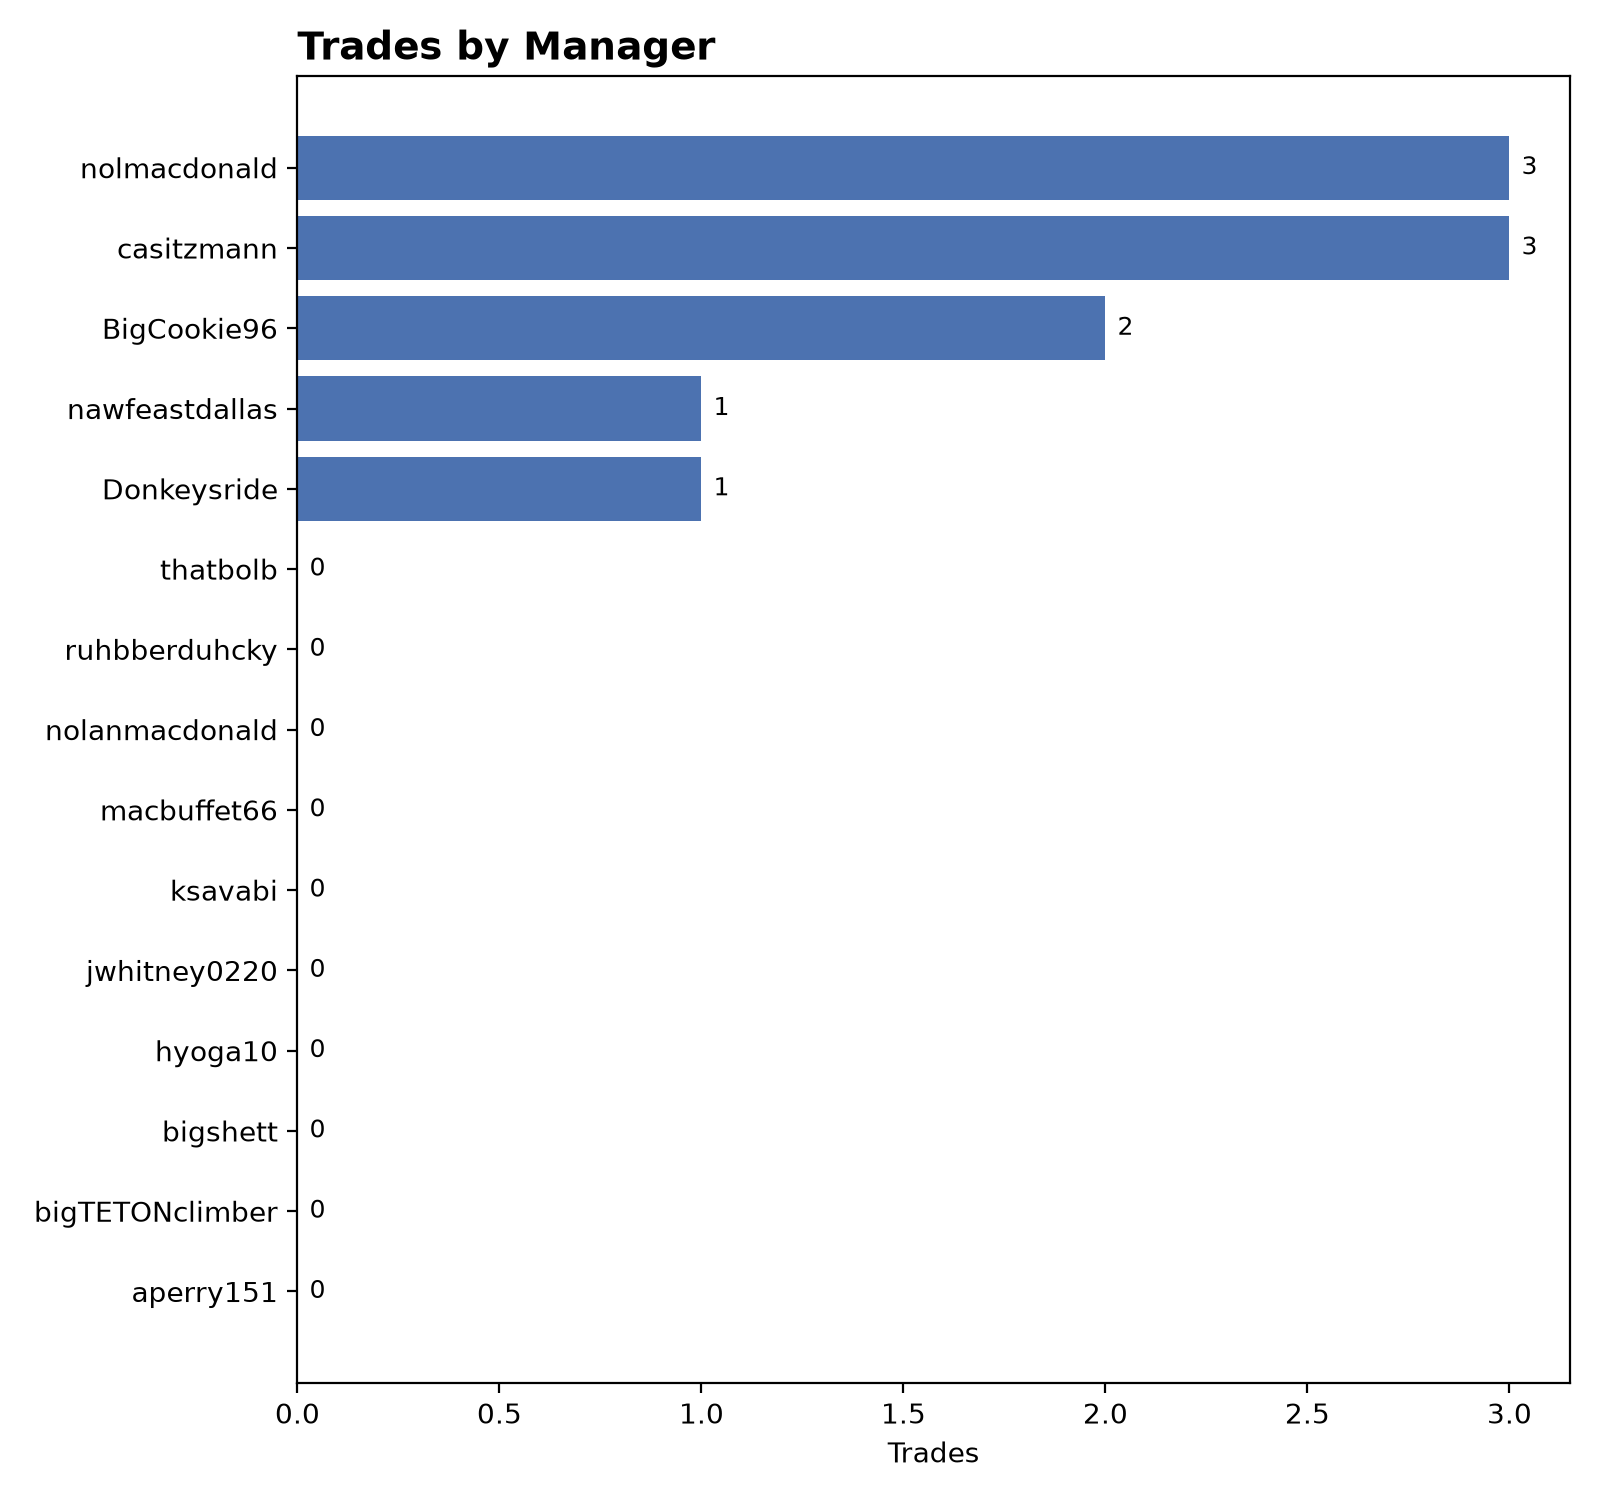

In [4]:
from IPython.display import Image, display

display(
    Image(
        filename="./demo/data/artifacts/1367225133634191360-trades/trades_by_manager.png"
    )
)  # Total trades per manager

`pairwise_trade_matrix` builds a symmetric manager x manager count matrix -- densify it the same way as `counts` before rendering, so a zero-trade manager still gets a dense, all-zero row and column:

In [5]:
from nuclearff.report import render_trades_heatmap
from nuclearff.sleeper.trades import pairwise_trade_matrix

raw_matrix = pairwise_trade_matrix(edges)
# pairwise_trade_matrix is only dense over managers who appear in
# edges -- a manager who never traded is missing as both a row and a
# column, so densify both before selecting the full all_managers set.
missing_cols = [m for m in all_managers if m not in raw_matrix.columns]
raw_matrix = raw_matrix.with_columns([pl.lit(0).alias(m) for m in missing_cols])
matrix = (
    pl.DataFrame({"manager": all_managers})
    .join(raw_matrix, on="manager", how="left")
    .fill_null(0)
    .select(["manager", *all_managers])
)
render_trades_heatmap(
    matrix, "./demo/data/artifacts/1367225133634191360-trades/trades_heatmap.png"
)

PosixPath('demo/data/artifacts/1367225133634191360-trades/trades_heatmap.png')

> **Why this matters:** this exact league's real data surfaces a case the plain row-join above doesn't handle on its own: `pairwise_trade_matrix`'s docstring says it's "dense over every manager who appears in `edges`" -- but with this league's own trade history, several all-time managers never traded *at all*, so they're missing as columns too, not just rows. A plain `.select(["manager", *all_managers])` on the joined frame raises `ColumnNotFoundError` for exactly those managers. The `missing_cols` step above adds them back as an explicit zero column before selecting -- worth remembering any time you densify a matrix-shaped DataFrame against a roster that's a strict superset of what the raw data contains.

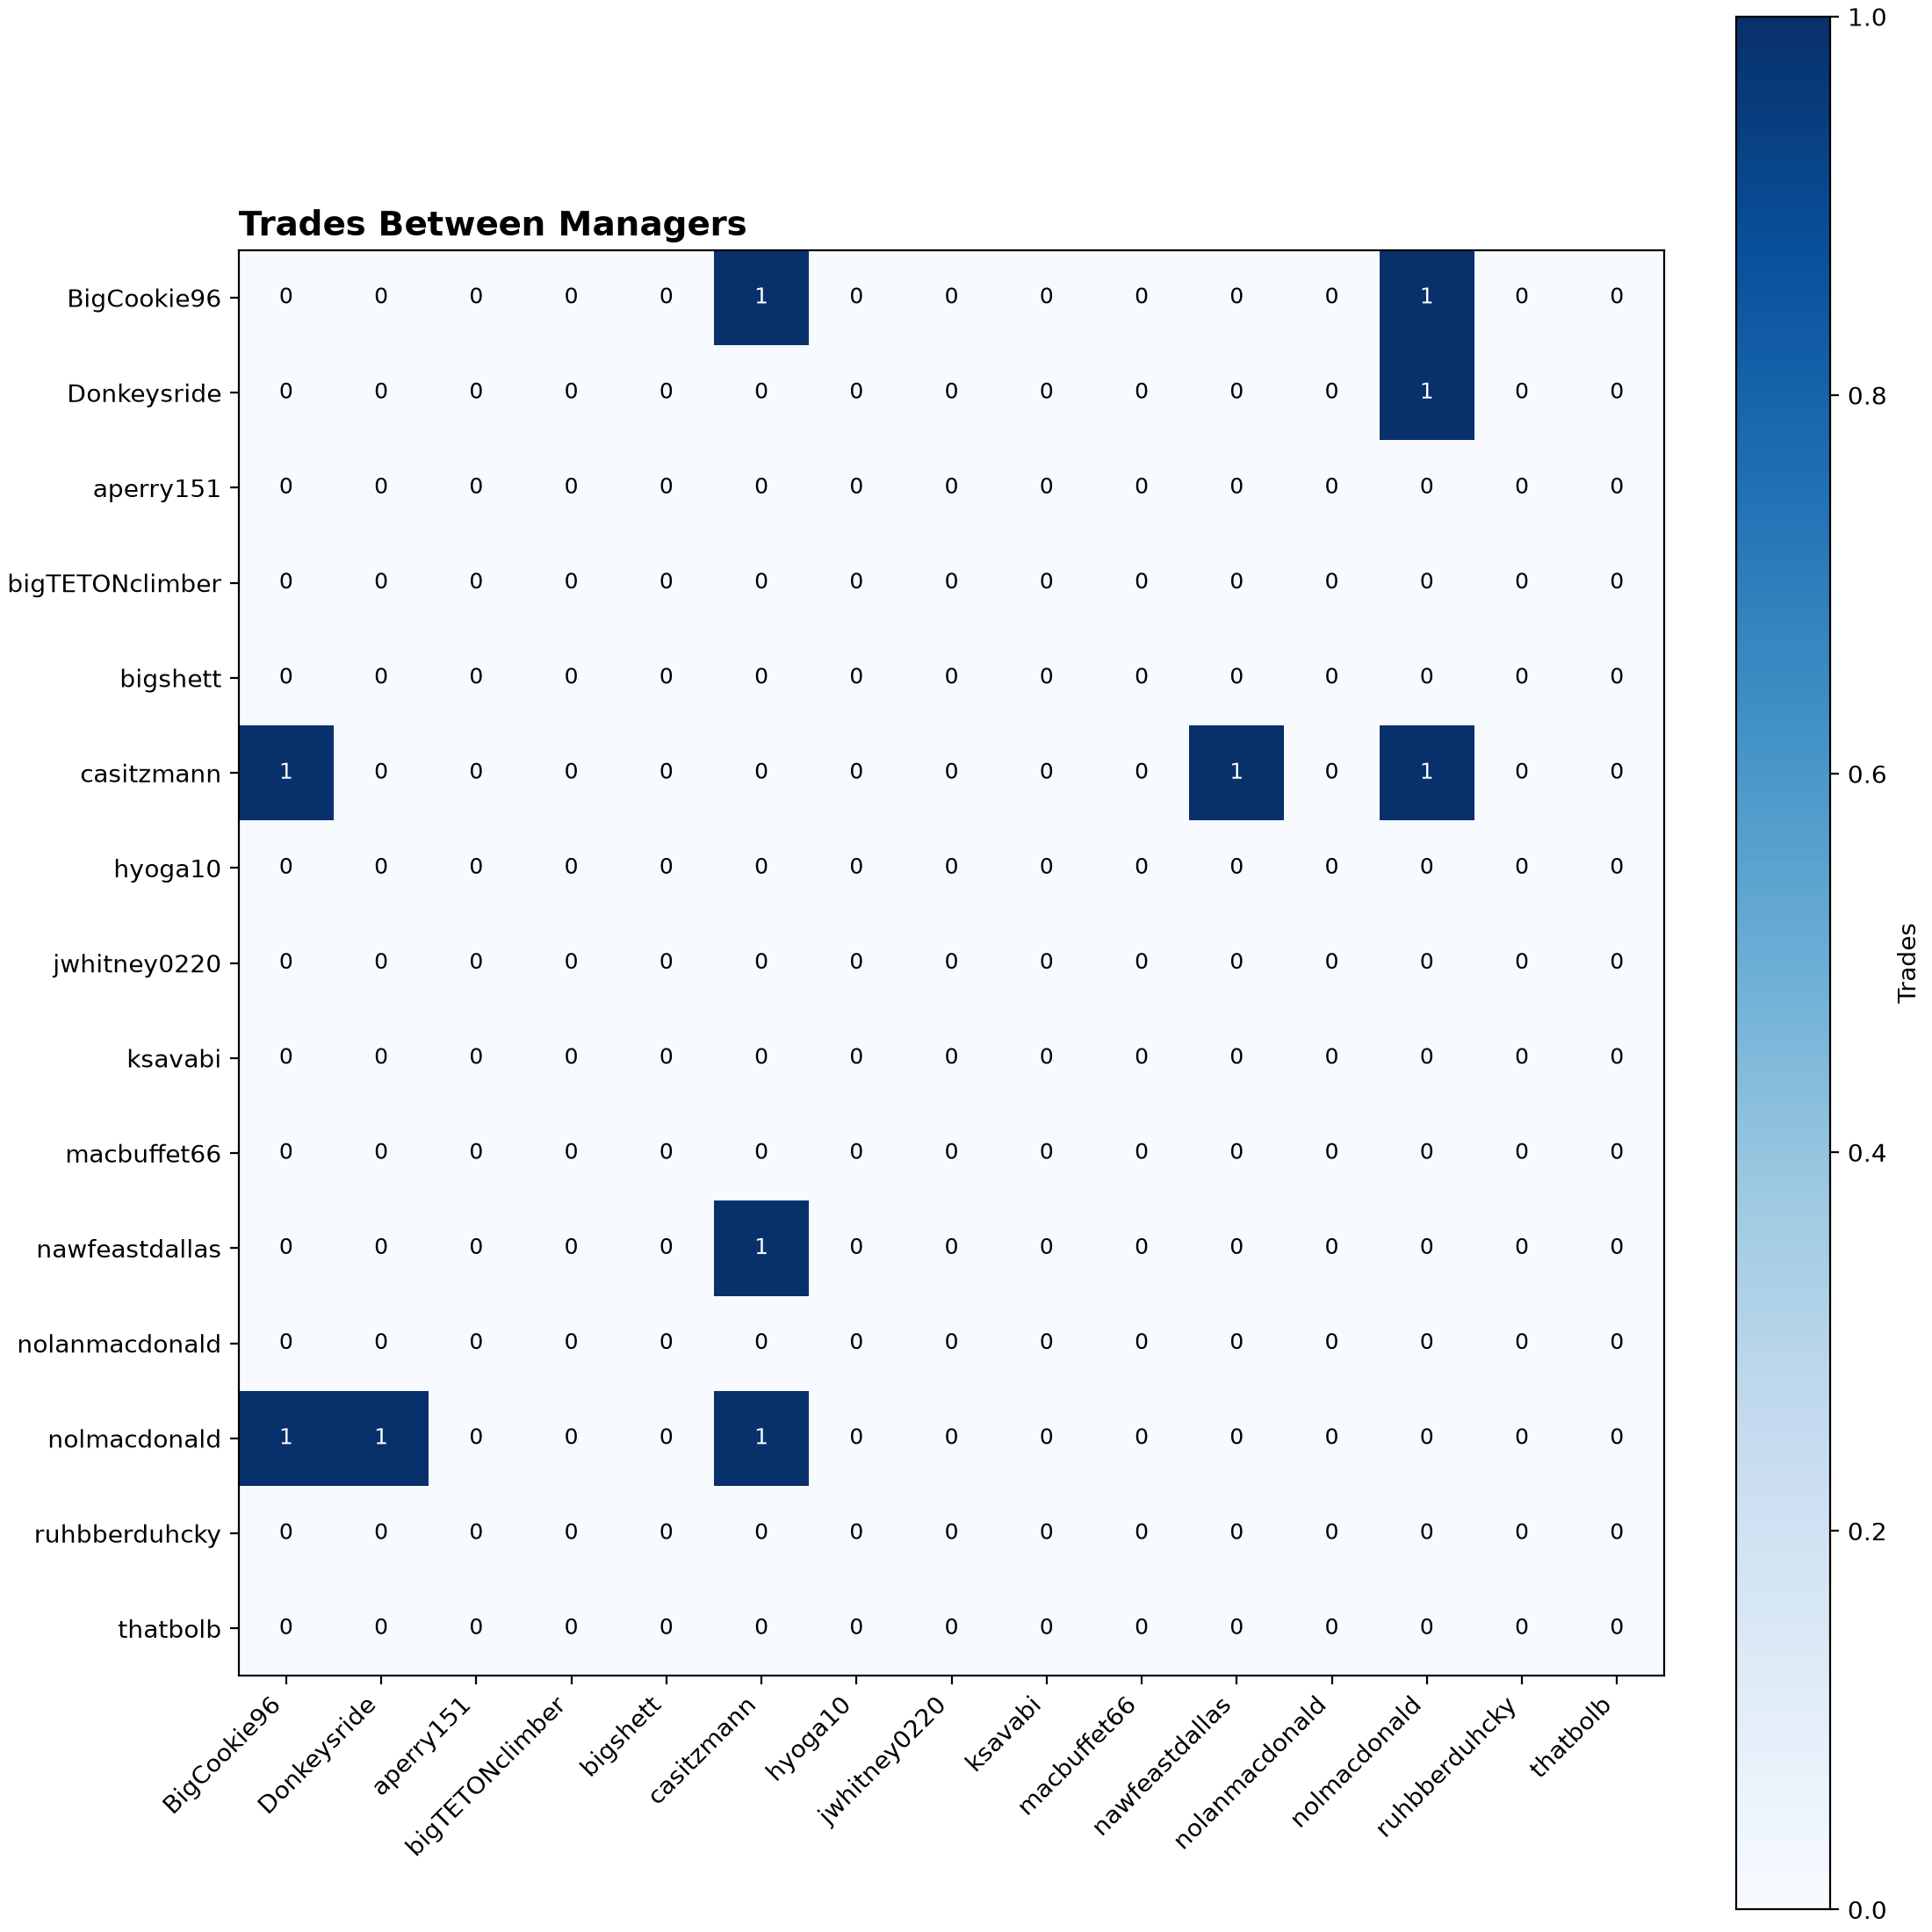

In [6]:
from IPython.display import Image, display

display(
    Image(
        filename="./demo/data/artifacts/1367225133634191360-trades/trades_heatmap.png"
    )
)  # Manager x manager trade heatmap

The heatmap is symmetric by construction (trades between two managers show the same count in both directions) with a 0 diagonal, since a manager can't trade with themselves.

## Trade network and chord diagram

`render_trade_network` draws a node-link graph -- one node per manager (sized by total trades), one edge per pair that has traded (widened by trade count):

In [7]:
from nuclearff.report import render_chord_diagram, render_trade_network

render_trade_network(
    counts_full.select("manager", "trades"),
    matrix,
    "./demo/data/artifacts/1367225133634191360-trades/trade_network.png",
)
render_chord_diagram(
    counts_full.select("manager", "trades"),
    matrix,
    "./demo/data/artifacts/1367225133634191360-trades/chord_diagram.png",
)

PosixPath('demo/data/artifacts/1367225133634191360-trades/chord_diagram.png')

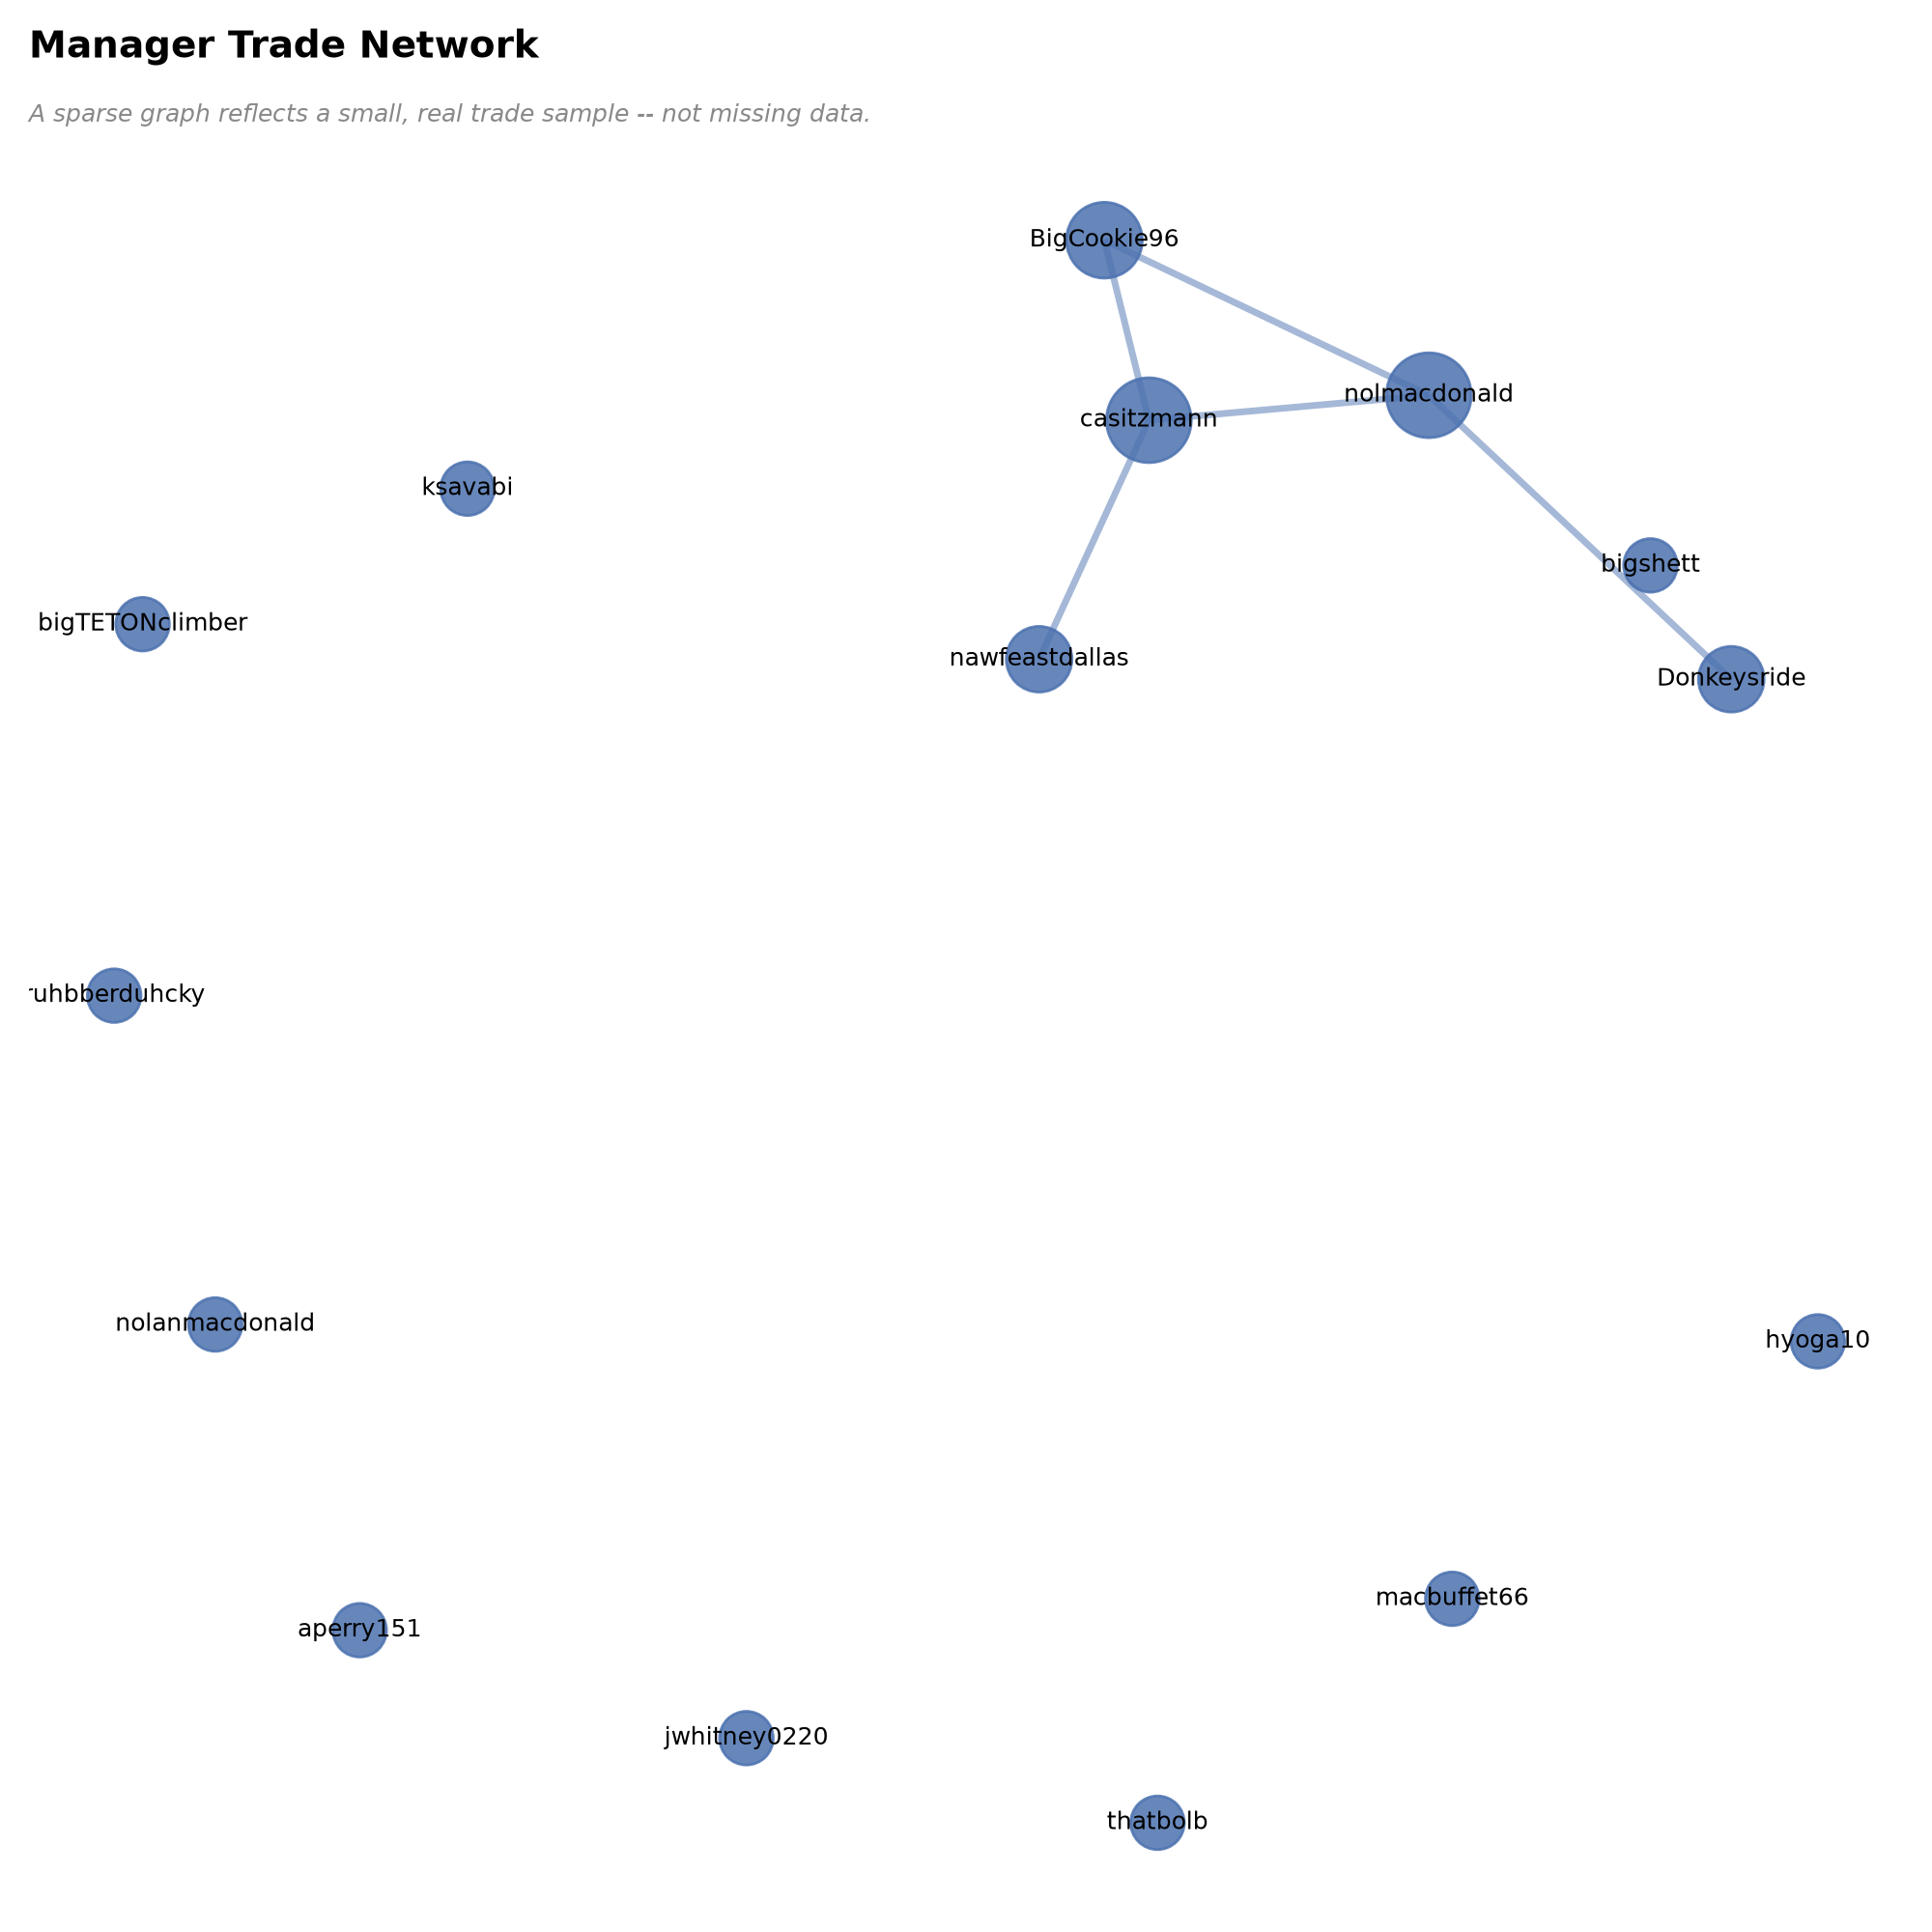

In [8]:
from IPython.display import Image, display

display(
    Image(filename="./demo/data/artifacts/1367225133634191360-trades/trade_network.png")
)  # Node-link graph of the manager trade network

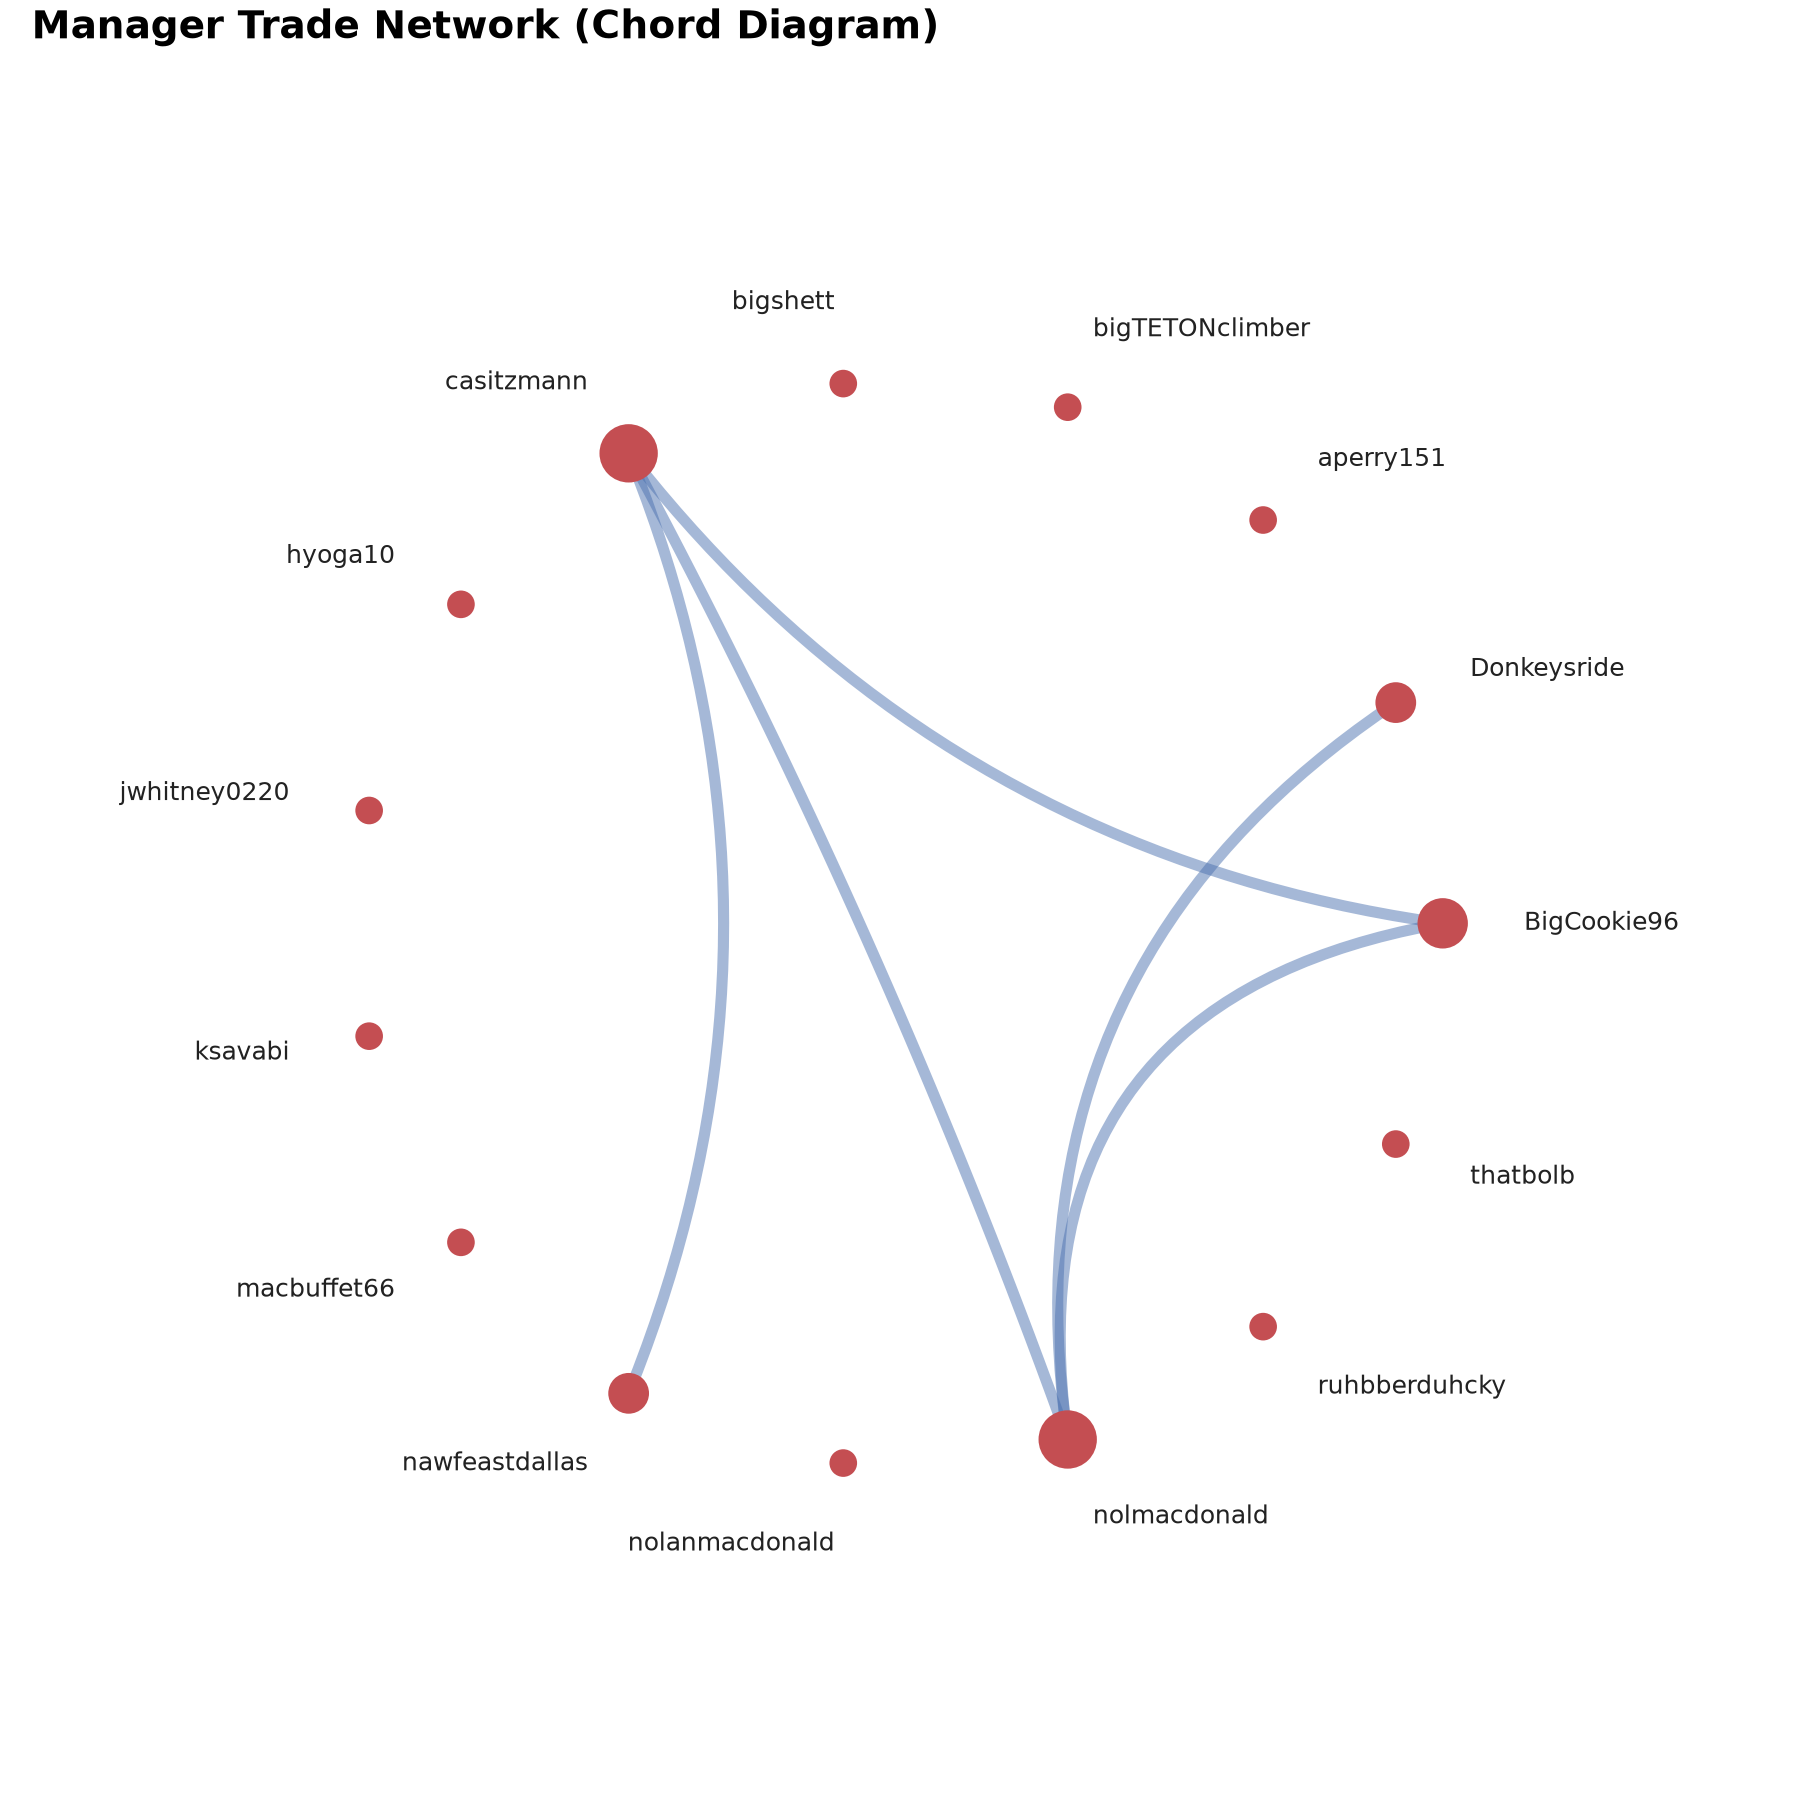

In [9]:
from IPython.display import Image, display

display(
    Image(filename="./demo/data/artifacts/1367225133634191360-trades/chord_diagram.png")
)  # Circular chord diagram

With a real league's actual trade volume, this graph is often genuinely sparse -- several managers may never connect to the rest of the league at all. That's real trading activity, not a rendering bug. The chord diagram shows the same relationships, drawn directly in matplotlib (not an interactive plotting library) to avoid a headless-browser dependency for one chart -- see this project's own decision notes for why that specific choice was made after a real `kaleido`/headless-Chrome dependency problem came up.

## Leaderboards

`render_trade_leaderboard` renders one reference row per manager (Trades, Unique Partners, Most Frequent Partner, Trades With Partner), and `render_manager_pair_leaderboard` shows the top 10 manager *pairs* by trade count -- unlike the heatmap, it only shows pairs that actually traded:

In [10]:
from nuclearff.report import render_manager_pair_leaderboard, render_trade_leaderboard
from nuclearff.sleeper.trades import top_manager_pairs

render_trade_leaderboard(
    counts_full,
    "./demo/data/artifacts/1367225133634191360-trades/trade_leaderboard.png",
)

pairs = top_manager_pairs(edges)
render_manager_pair_leaderboard(
    pairs,
    "./demo/data/artifacts/1367225133634191360-trades/manager_pair_leaderboard.png",
)

PosixPath('demo/data/artifacts/1367225133634191360-trades/manager_pair_leaderboard.png')

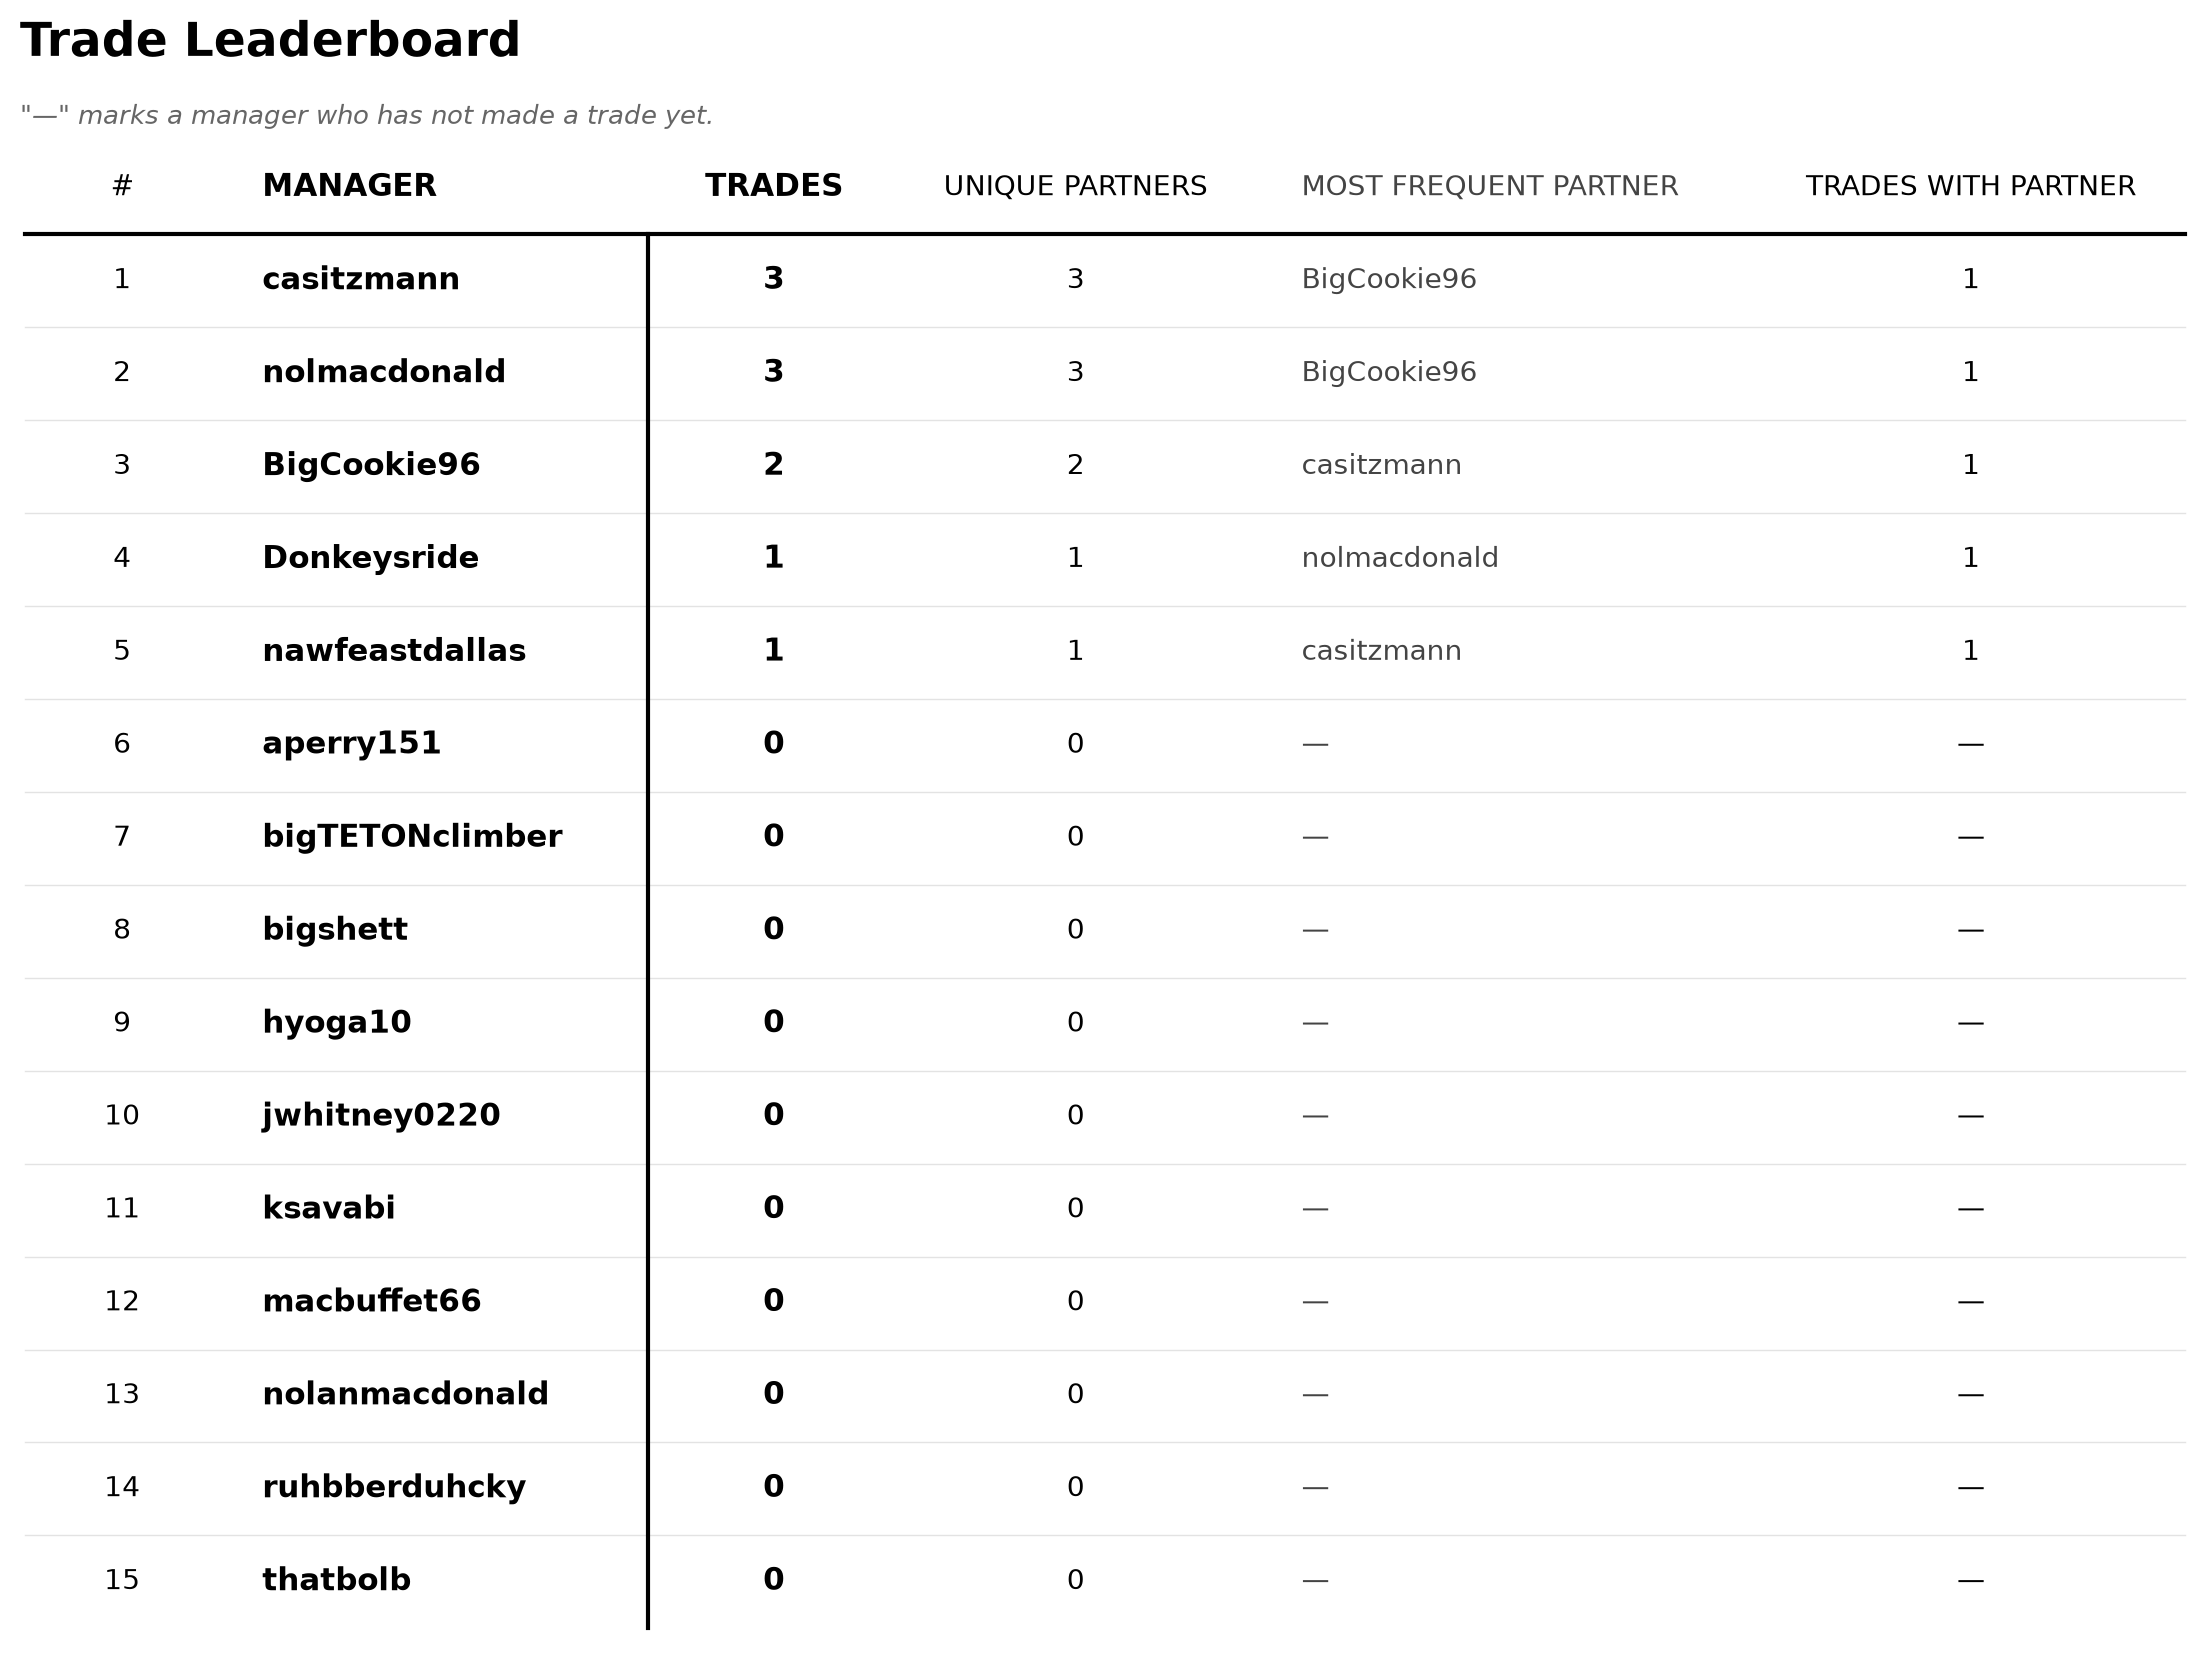

In [11]:
from IPython.display import Image, display

display(
    Image(
        filename="./demo/data/artifacts/1367225133634191360-trades/trade_leaderboard.png"
    )
)  # Trade leaderboard reference table

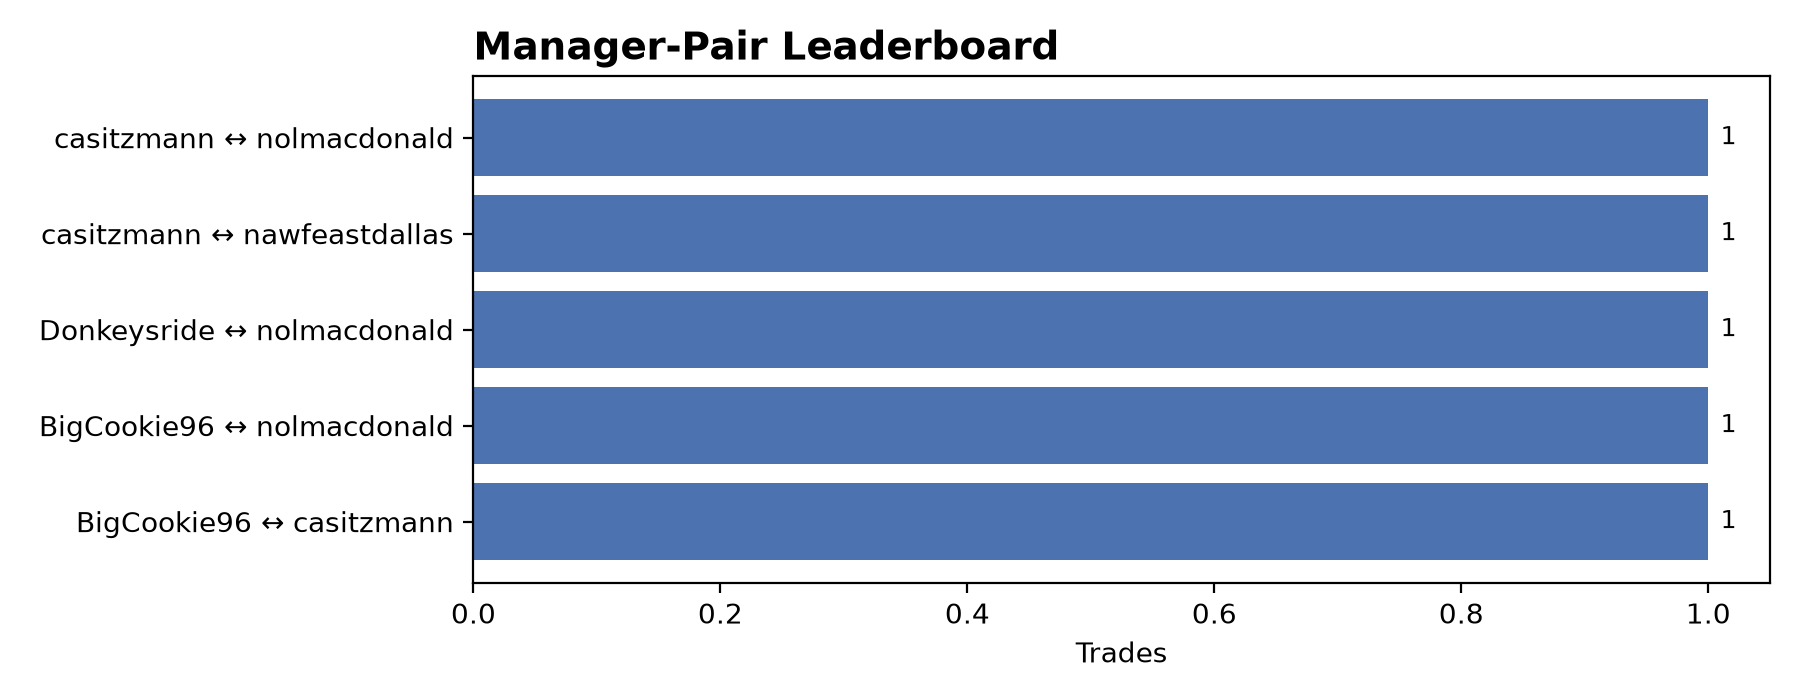

In [12]:
from IPython.display import Image, display

display(
    Image(
        filename="./demo/data/artifacts/1367225133634191360-trades/manager_pair_leaderboard.png"
    )
)  # Top manager pairs by trade count

A zero-trade manager still gets a full row on the leaderboard, with `—` in place of a partner that doesn't exist. The pair leaderboard shows each pair once -- manager names are sorted alphabetically before grouping, so an A-B and B-A row for the same pair can't both exist.

## Trades over time

`trades_by_season` and `total_trades_by_season` feed `render_trades_over_time` (one thin line per manager plus a bold league-wide total) and `render_manager_season_heatmap` (the same data as a dense manager x season grid):

In [13]:
from nuclearff.report import render_manager_season_heatmap, render_trades_over_time
from nuclearff.sleeper.trades import total_trades_by_season, trades_by_season

by_season = trades_by_season(edges)
totals = total_trades_by_season(edges)
render_trades_over_time(
    by_season,
    totals,
    "./demo/data/artifacts/1367225133634191360-trades/trades_over_time.png",
)

PosixPath('demo/data/artifacts/1367225133634191360-trades/trades_over_time.png')

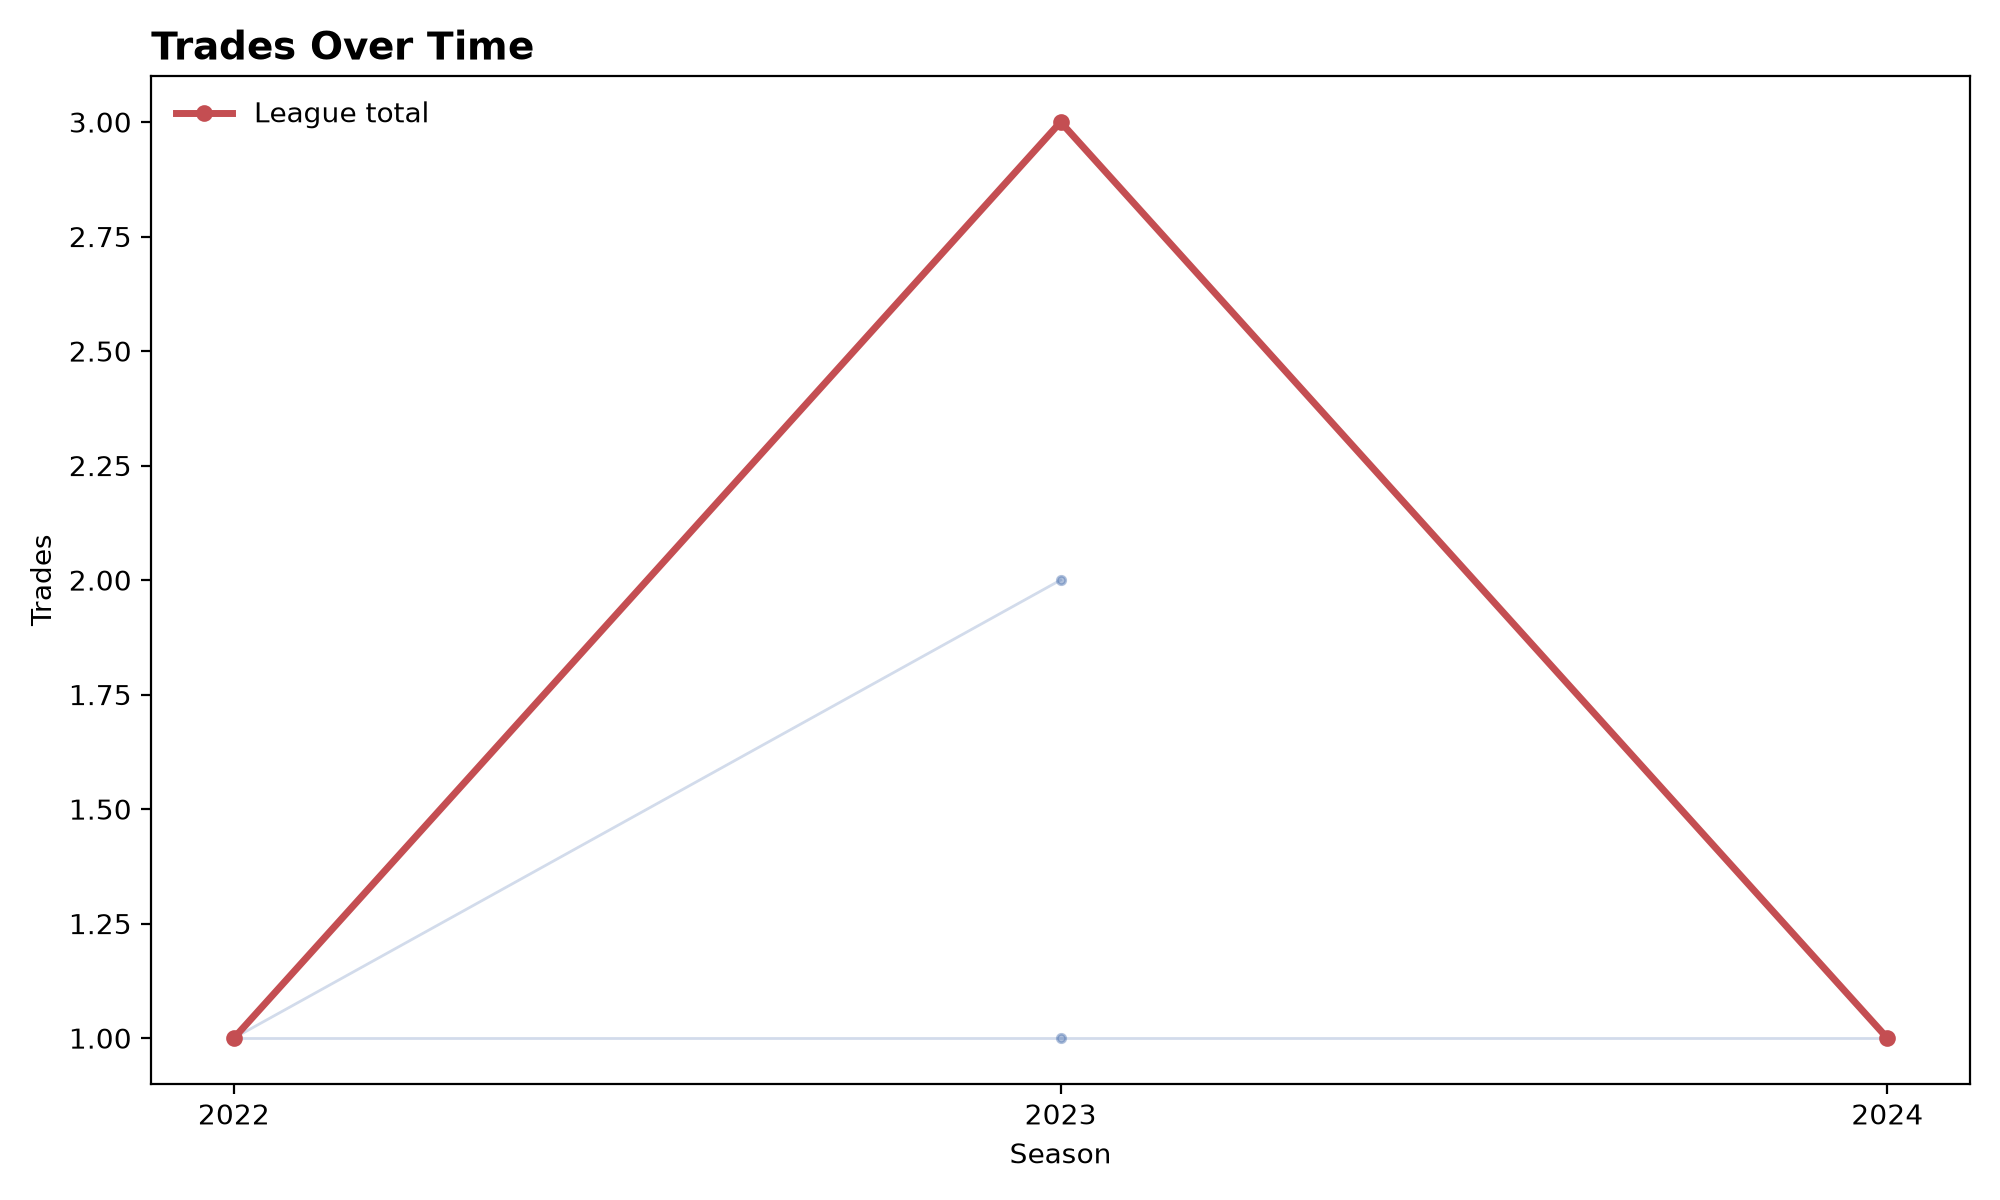

In [14]:
from IPython.display import Image, display

display(
    Image(
        filename="./demo/data/artifacts/1367225133634191360-trades/trades_over_time.png"
    )
)  # Trades by season, one line per manager plus a league total

`render_manager_season_heatmap` needs a fully dense manager x season matrix -- `trades_by_season` alone is only dense over combinations that actually had a trade (deliberately, so it stays usable for the line chart above too). Densify it the same way the CLI's own `report trades` command does, over every manager and every season in this league's real history:

In [15]:
all_seasons = sorted(standings["season"].unique().to_list())
by_season_lookup = {
    (row["manager"], row["season"]): row["trades"] for row in by_season.to_dicts()
}
season_matrix = pl.DataFrame(
    [
        {
            "manager": manager,
            **{
                str(season): by_season_lookup.get((manager, season), 0)
                for season in all_seasons
            },
        }
        for manager in all_managers
    ]
)
render_manager_season_heatmap(
    season_matrix,
    "./demo/data/artifacts/1367225133634191360-trades/manager_season_heatmap.png",
)

PosixPath('demo/data/artifacts/1367225133634191360-trades/manager_season_heatmap.png')

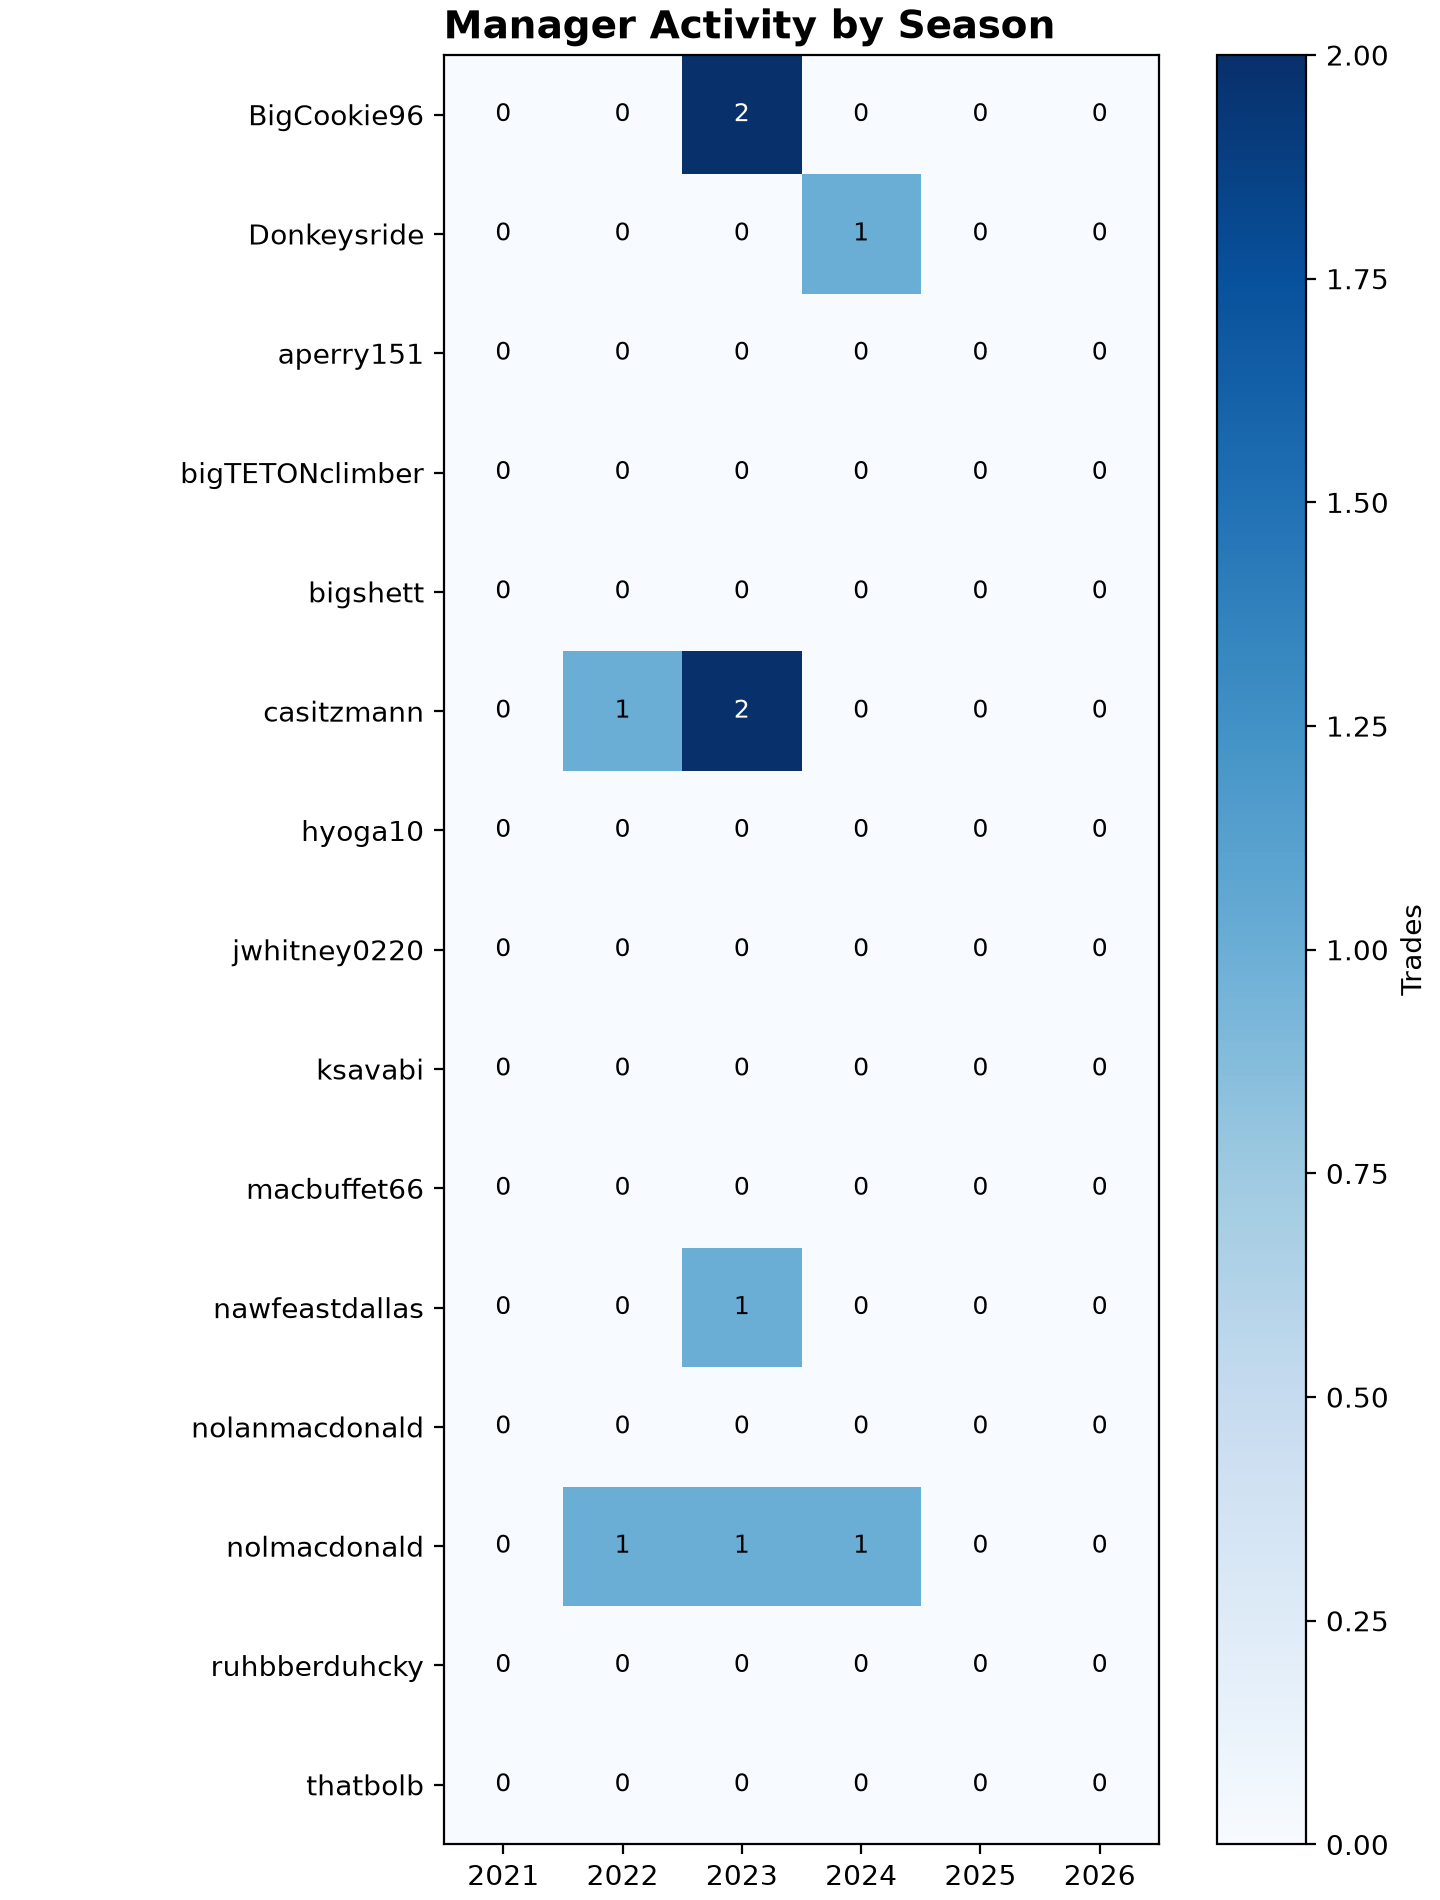

In [16]:
from IPython.display import Image, display

display(
    Image(
        filename="./demo/data/artifacts/1367225133634191360-trades/manager_season_heatmap.png"
    )
)  # Manager x season trade heatmap

The league total counts each trade once regardless of how many managers it involved -- summing every manager's own line would roughly double-count a season's real trade volume, since most trades involve exactly two managers.

## Cumulative trades and partner diversity

`cumulative_trade_counts` and `render_cumulative_trades` answer "who became the league's most prolific trader, and when did they take the lead":

In [17]:
from nuclearff.report import render_cumulative_trades, render_trade_partner_diversity
from nuclearff.sleeper.trades import cumulative_trade_counts

cumulative = cumulative_trade_counts(edges)
render_cumulative_trades(
    cumulative, "./demo/data/artifacts/1367225133634191360-trades/cumulative_trades.png"
)

render_trade_partner_diversity(
    counts_full.select("manager", "trades", "unique_partners"),
    "./demo/data/artifacts/1367225133634191360-trades/trade_partner_diversity.png",
)

PosixPath('demo/data/artifacts/1367225133634191360-trades/trade_partner_diversity.png')

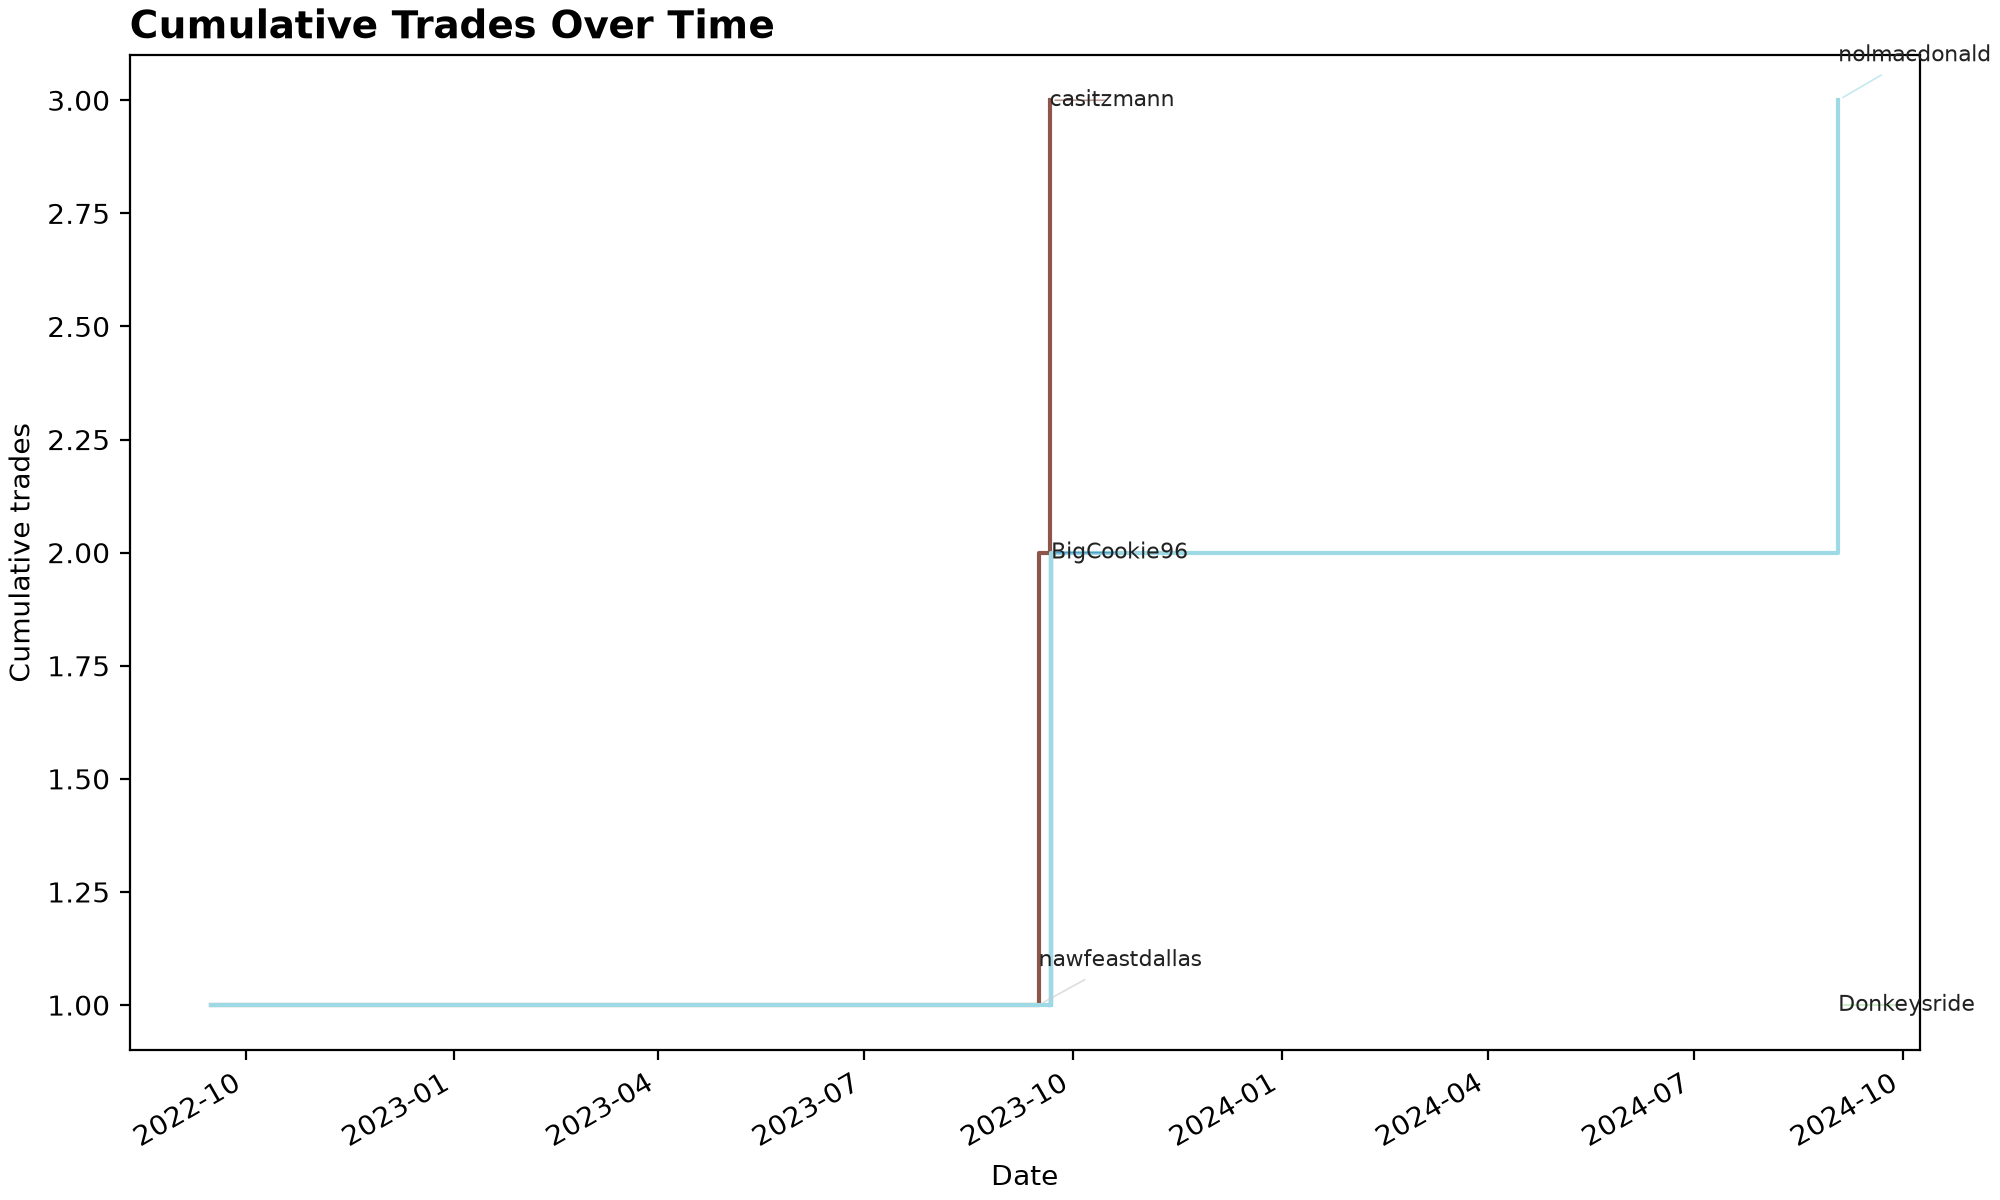

In [18]:
from IPython.display import Image, display

display(
    Image(
        filename="./demo/data/artifacts/1367225133634191360-trades/cumulative_trades.png"
    )
)  # Step chart of cumulative trades per manager over time

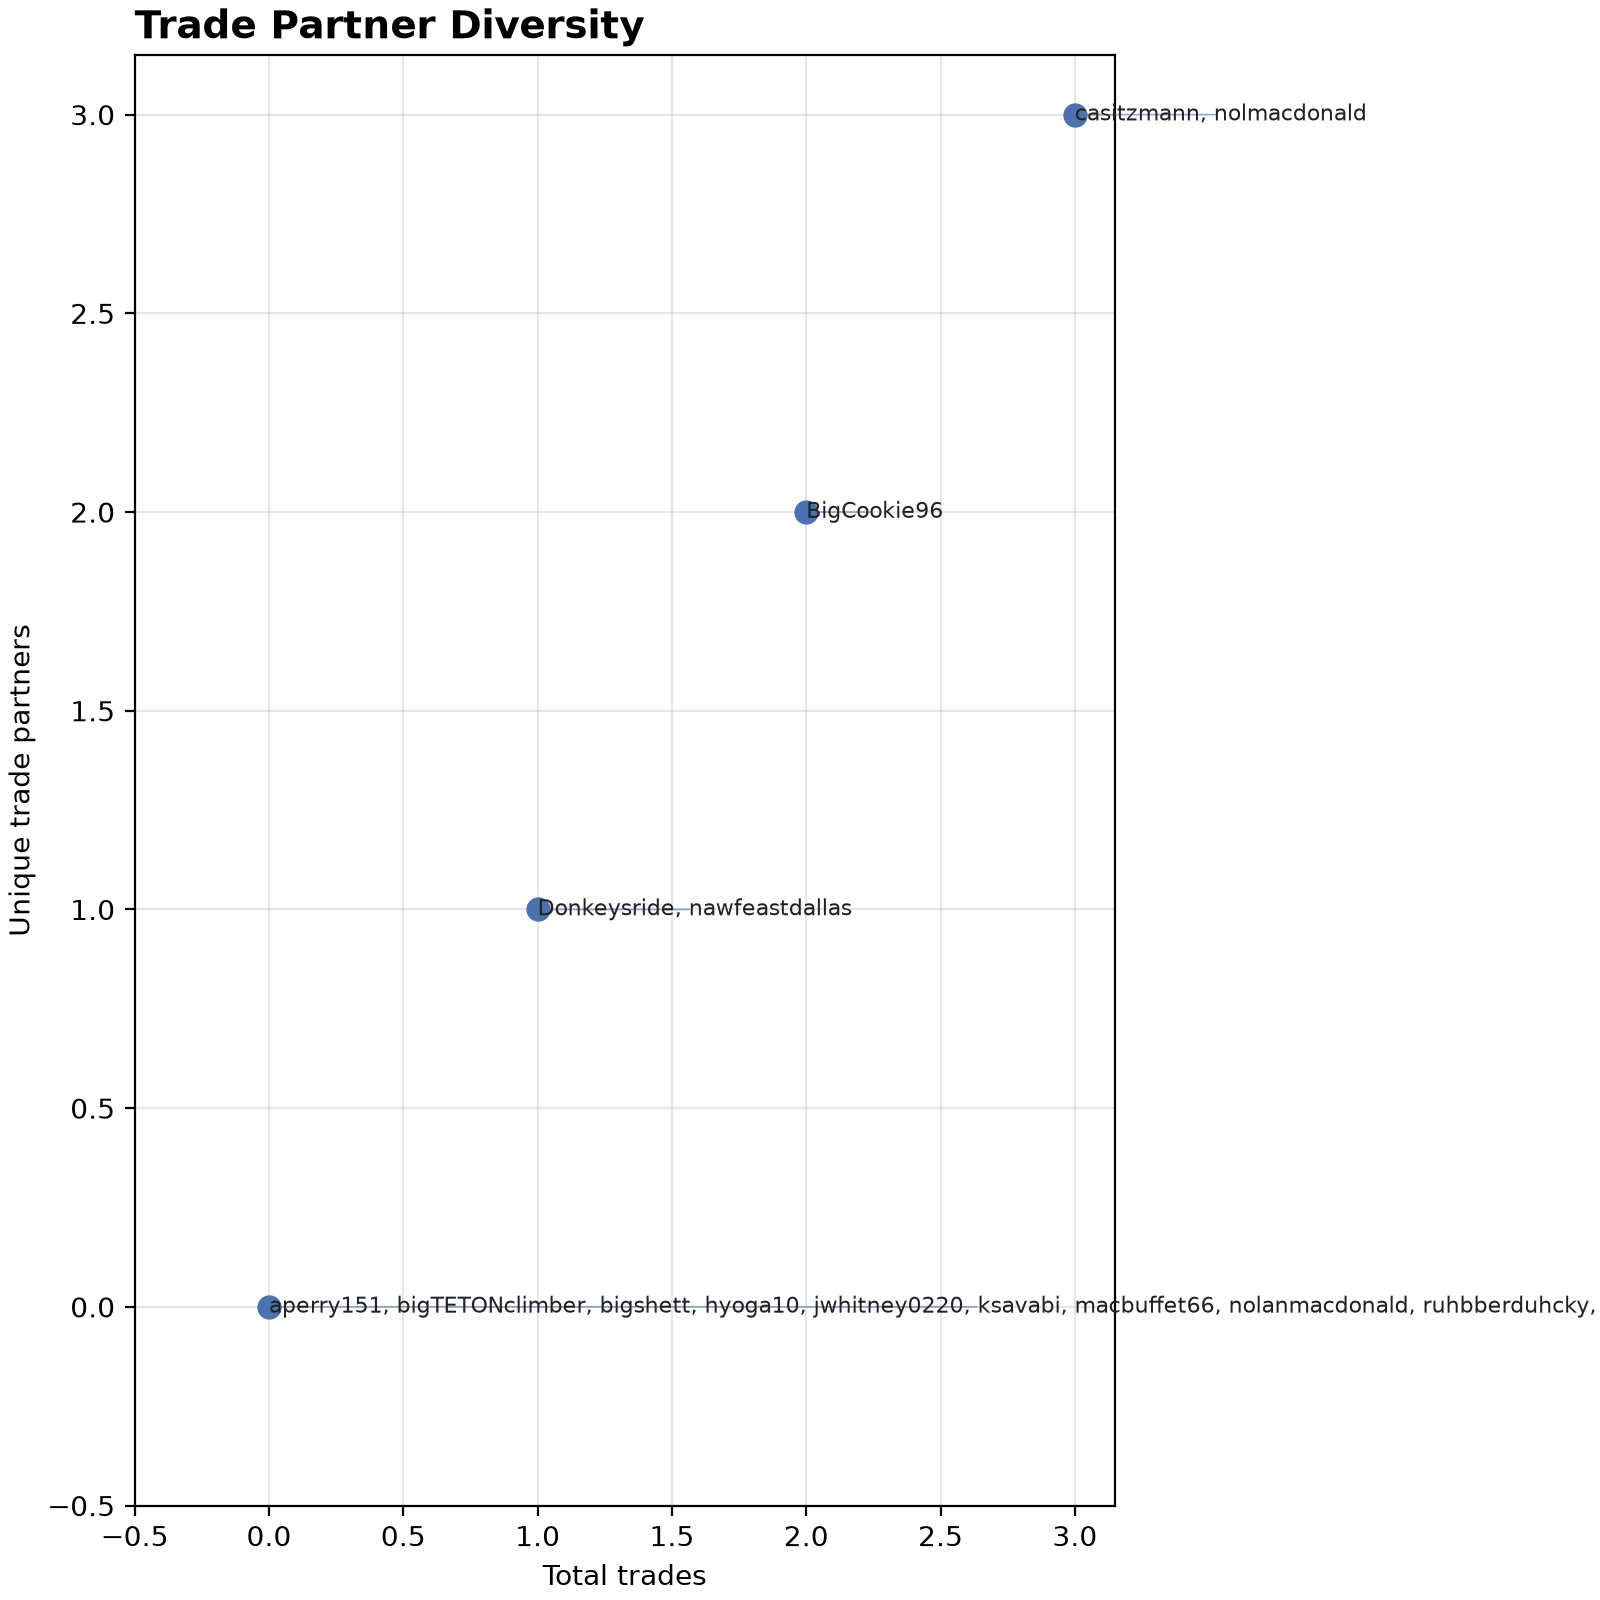

In [19]:
from IPython.display import Image, display

display(
    Image(
        filename="./demo/data/artifacts/1367225133634191360-trades/trade_partner_diversity.png"
    )
)  # Total trades vs. unique trade partners

The partner-diversity scatter separates a manager who trades widely from one who repeatedly trades with the same one or two people -- X axis is total trades, Y axis is unique partners. Every zero-trade manager collapses into a single labeled point at the origin rather than several fully-overlapping ones.

## Reading these charts correctly

Three real details from this exact data apply across every chart above, not just one:

- **A manager needs a resolvable Sleeper display name to appear at all.** A real trade with a roster whose owner isn't in that season's user list contributes to no chart.
- **Sleeper allows more than two rosters in a single trade.** Every trade-counting aggregate here de-duplicates by the underlying transaction, not by exploded pairwise edges -- a 3-team trade contributes one trade to each of the three managers involved, not two.
- **Manager identity is a display name, not a stable id**, and a league with two similarly-spelled display names shows exactly why that matters -- nothing here merges similar-looking names automatically.

## What's Next

Trades are one lens on league history. `15_wins_and_leagues.ipynb` covers two more: a manager's cumulative win total across their real career, and a full snapshot of every league a Sleeper user belongs to.

## See Also

- `04_capturing_a_league.ipynb` -- `sleeper fetch-league --transactions`, the data this chapter reads.
- [Trade Network Analysis](https://nolmacdonald.github.io/nuclearff/tutorial/14_trade_network.html) -- the matching docs page.